# Modelagem — alfabetização municipal (classificação)

**Escopo:** modelagem que decorre diretamente do EDA em
`3.0-mc-eda-base-completa.ipynb` (grão, poda de colinearidade, ablação por
família) e da clusterização em `4.0-mc-kmeans-clusterizacao-municipios.ipynb`
(resposta à Q3). Fecha as perguntas **Q1, Q2, Q4 e Q5** do desafio; a Q3 não é
refeita aqui — ver o notebook `4.0`.

**Decisão de arquitetura (registrada com o time):** tudo modelado como
**classificação**, no grão **município-ano**, porque:

- o grão mínimo real dos dados é o município (nenhuma feature descreve o
  aluno individualmente — ver `3.0`, seção 2);
- "regressão binomial da taxa" e "classificação ponderada de aluno
  alfabetizado" são **o mesmo modelo** (mesmo link logit, mesma log-loss) —
  aqui isso é implementado como classificação ponderada por `n_alunos`;
- a pergunta de meta (Q4) é uma decisão binária por construção.

**Conjunto de features:** os **49 representantes** da poda de colinearidade
(seção 13 do `3.0`, |ρ| ≥ 0,90 → 1 representante por cluster). 2023 é excluído
porque `ctx_inep_*_lag1` e `ctx_inep_mun_meta` são 100% nulos nesse ano
(primeira edição da série, sem histórico anterior) — desenvolvimento em
**2024**, teste temporal final em **2025**, mesma convenção usada nos
notebooks `Q1`-`Q4` do time, para permitir comparação direta dos números.

## 1. Setup e carregamento

In [1]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score,
    mean_absolute_error,
    mean_squared_error,
    precision_recall_curve,
    r2_score,
    recall_score,
    precision_score,
    roc_auc_score,
)
from sklearn.model_selection import KFold, StratifiedKFold
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", message=".*IProgress.*")  # aviso do tqdm/ipywidgets
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 160)
plt.rcParams["figure.dpi"] = 100
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

RNG = 42

In [2]:
# 49 representantes da poda de colinearidade (3.0, seção 13)
FEATURES = [
    "ctx_atu_fundamental", "ctx_atu_fundamental_anos_iniciais", "ctx_atu_fundamental_3_ano",
    "ctx_atu_fundamental_4_ano", "ctx_atu_fundamental_5_ano", "ctx_atu_fundamental_2_ano",
    "ctx_atu_fundamental_1_ano", "ctx_atu_medio_2_serie", "ctx_atu_medio_3_serie",
    "ctx_atu_medio_1_serie", "ctx_atu_fundamental_7_ano", "ctx_atu_fundamental_6_ano",
    "ctx_atu_fundamental_8_ano", "ctx_atu_fundamental_9_ano", "ctx_ibge_populacao_residente",
    "ctx_atu_medio_4_serie", "ctx_atu_educacao_infantil", "ctx_atu_creche", "ctx_atu_pre_escola",
    "ctx_atu_medio_nao_seriado", "ctx_atu_multietapa", "ctx_atlas_taxa_frequencia_4a5",
    "ctx_atlas_taxa_frequencia_0a3", "ctx_ibge_area_km2",
    "ctx_inep_mun_percentual_participacao_lag1", "ctx_inep_uf_percentual_participacao_lag1",
    "ctx_atlas_taxa_frequencia_6a14", "ctx_atlas_taxa_frequencia_liquida_fundamental",
    "ctx_atlas_taxa_maes_10a14", "ctx_inep_mun_media_portugues_lag1", "ctx_inep_mun_meta",
    "ctx_inep_uf_media_portugues_lag1", "ctx_inep_uf_meta", "ctx_atlas_indice_theil",
    "ctx_fundeb_ponderador_nse_uf", "ctx_atlas_taxa_analfabetismo_11a14",
    "ctx_atlas_taxa_analfabetismo_15a17", "ctx_atlas_idhm_educacao",
    "ctx_atlas_mortalidade_ate_1_ano", "ctx_ibge_renda_domiciliar_per_capita_mediana",
    "ctx_atlas_taxa_analfabetismo_15mais", "ctx_atlas_taxa_densidade_domiciliar",
    "ctx_atlas_percentual_domicilios_energia", "ctx_atlas_percentual_domicilios_agua",
    "ctx_atlas_taxa_maes_chefes_familia", "ctx_atlas_expectativa_anos_estudo",
    "ctx_ibge_pct_populacao_rural", "ctx_ibge_pct_esgoto_adequado",
    "ctx_atlas_taxa_trabalho_infantil_10a14",
]
print(f"{len(FEATURES)} features (poda de 76 -> 49, |rho| < 0.90 entre representantes)")

DEST = Path("../data/processed/base_analitica")
cols = ["ano", "id_uf", "id_municipio", "label_alfabetizado"] + FEATURES
dfs = []
for p in sorted(DEST.glob("ano=*")):
    ano = int(p.name.split("=")[1])
    if ano == 2023:
        continue  # ctx_inep_*_lag1 e meta 100% nulos (sem historico anterior)
    sub = pd.read_parquet(p, columns=cols)
    sub["ano"] = ano
    dfs.append(sub)

df = pd.concat(dfs, ignore_index=True)
print(f"{len(df):,} linhas (aluno-ano, 2024-2025) x {df.shape[1]} colunas")

49 features (poda de 76 -> 49, |rho| < 0.90 entre representantes)


3,817,923 linhas (aluno-ano, 2024-2025) x 53 colunas


## 2. Agregação para o grão município-ano

In [3]:
agg = {c: "mean" for c in FEATURES}  # ja constantes por municipio-ano; mean = no-op seguro
agg["label_alfabetizado"] = ["sum", "count"]

muni = df.groupby(["ano", "id_uf", "id_municipio"]).agg(agg)
# agg com dict misto (mean + [sum, count]) sempre devolve colunas MultiIndex
muni.columns = ["_".join(str(x) for x in c if x) for c in muni.columns]
muni = muni.rename(columns={f"{c}_mean": c for c in FEATURES})
muni = muni.rename(columns={
    "label_alfabetizado_sum": "n_alfabetizados",
    "label_alfabetizado_count": "n_alunos",
})
muni["n_nao_alfabetizados"] = muni["n_alunos"] - muni["n_alfabetizados"]
muni["taxa_realizada"] = muni["n_alfabetizados"] / muni["n_alunos"] * 100
muni = muni.reset_index()

UF_INFO = {
    11: ("RO", "Norte"), 12: ("AC", "Norte"), 13: ("AM", "Norte"), 14: ("RR", "Norte"),
    15: ("PA", "Norte"), 16: ("AP", "Norte"), 17: ("TO", "Norte"),
    21: ("MA", "Nordeste"), 22: ("PI", "Nordeste"), 23: ("CE", "Nordeste"),
    24: ("RN", "Nordeste"), 25: ("PB", "Nordeste"), 26: ("PE", "Nordeste"),
    27: ("AL", "Nordeste"), 28: ("SE", "Nordeste"), 29: ("BA", "Nordeste"),
    31: ("MG", "Sudeste"), 32: ("ES", "Sudeste"), 33: ("RJ", "Sudeste"), 35: ("SP", "Sudeste"),
    41: ("PR", "Sul"), 42: ("SC", "Sul"), 43: ("RS", "Sul"),
    50: ("MS", "Centro-Oeste"), 51: ("MT", "Centro-Oeste"),
    52: ("GO", "Centro-Oeste"), 53: ("DF", "Centro-Oeste"),
}
muni["regiao"] = muni["id_uf"].map(lambda x: UF_INFO.get(x, ("??", "??"))[1])
muni["meta"] = muni["ctx_inep_mun_meta"]

print(f"{len(muni):,} linhas municipio-ano  |  {muni['id_municipio'].nunique():,} municipios distintos")
print(muni.groupby("ano").size())
print("\nnulos (%) nas 49 features, no grao municipio-ano:")
print((muni[FEATURES].isna().mean() * 100).round(2).sort_values(ascending=False).head(10))

11,073 linhas municipio-ano  |  5,564 municipios distintos
ano
2024    5517
2025    5556
dtype: int64

nulos (%) nas 49 features, no grao municipio-ano:
ctx_atu_medio_nao_seriado    98.42
ctx_atu_medio_4_serie        97.86
ctx_atu_medio_3_serie        79.75
ctx_atu_medio_1_serie        79.73
ctx_atu_medio_2_serie        79.72
ctx_atu_multietapa           40.64
ctx_atu_fundamental_9_ano    28.50
ctx_atu_fundamental_8_ano    28.11
ctx_atu_fundamental_7_ano    27.64
ctx_atu_fundamental_6_ano    26.89
dtype: float64


## 3. Split temporal — 2024 (desenvolvimento) / 2025 (teste)

Mesma convenção do time (`Q1`-`Q4`): todas as decisões de modelo, feature e
hiperparâmetro são tomadas só com 2024. 2025 é usado uma única vez, no final,
como teste temporal.

In [4]:
dev = muni[muni["ano"] == 2024].reset_index(drop=True)
oot = muni[muni["ano"] == 2025].reset_index(drop=True)
print(f"desenvolvimento (2024): {len(dev):,} municipios")
print(f"teste temporal (2025):  {len(oot):,} municipios")

desenvolvimento (2024): 5,517 municipios
teste temporal (2025):  5,556 municipios


## 4. Modelo central — probabilidade de alfabetização (classificação ponderada)

Implementação da equivalência "regressão binomial == classificação
ponderada": cada município-ano vira **duas linhas** — uma com `y=1` e peso
`n_alfabetizados`, outra com `y=0` e peso `n_nao_alfabetizados`. O
classificador ajustado com esses pesos converge para a mesma solução de uma
regressão binomial da taxa, mas usa qualquer classificador do scikit-learn e
plugа direto em `permutation_importance`/SHAP.

A saída (`predict_proba`) já **é** a taxa municipal esperada — é o que
alimenta a Q1 (fatores), a Q2 (risco, via nível) e a projeção para o aluno
individual (`P(alfabetizado) = taxa esperada do seu município`).

In [5]:
def expandir_binomial(base, features):
    pos = base.copy(); pos["y"] = 1; pos["w"] = pos["n_alfabetizados"]
    neg = base.copy(); neg["y"] = 0; neg["w"] = neg["n_nao_alfabetizados"]
    out = pd.concat([pos, neg], ignore_index=True)
    return out[out["w"] > 0]


def logit_pipeline():
    return make_pipeline(
        SimpleImputer(strategy="median"),
        StandardScaler(),
        LogisticRegression(max_iter=3000),
    )


def hgb_pipeline():
    return make_pipeline(
        SimpleImputer(strategy="median"),
        HistGradientBoostingClassifier(random_state=RNG, max_depth=6, max_iter=200,
                                        learning_rate=0.06),
    )


def cv_taxa(base, features, construtor, n_splits=5):
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=RNG)
    maes, r2s = [], []
    for tr_idx, va_idx in kf.split(base):
        tr, va = base.iloc[tr_idx], base.iloc[va_idx]
        tr_exp = expandir_binomial(tr, features)
        modelo = construtor()
        modelo.fit(tr_exp[features], tr_exp["y"], **{
            f"{modelo.steps[-1][0]}__sample_weight": tr_exp["w"].to_numpy()
        })
        pred = modelo.predict_proba(va[features])[:, 1] * 100
        maes.append(mean_absolute_error(va["taxa_realizada"], pred))
        r2s.append(r2_score(va["taxa_realizada"], pred))
    return np.mean(maes), np.std(maes), np.mean(r2s)

In [6]:
resultados_central = []
for nome, construtor in [("logit ponderada", logit_pipeline), ("HistGB ponderado", hgb_pipeline)]:
    mae, mae_std, r2 = cv_taxa(dev, FEATURES, construtor)
    resultados_central.append((nome, mae, mae_std, r2))

# baseline de negocio: media historica lag1 nao esta nas features finais (foi podada
# em favor de media_portugues_lag1) -> baseline = media da taxa de 2024
baseline_mae = mean_absolute_error(dev["taxa_realizada"],
                                    np.full(len(dev), dev["taxa_realizada"].mean()))
resultados_central.append(("baseline (media 2024)", baseline_mae, 0.0, 0.0))

tab_central = pd.DataFrame(resultados_central, columns=["modelo", "MAE_cv", "MAE_cv_std", "R2_cv"])
tab_central.round(3)

,modelo,MAE_cv,MAE_cv_std,R2_cv
0,logit ponderada,10.068,0.210,0.521
1,HistGB ponderado,8.537,0.061,0.632
2,baseline (media 2024),15.766,0.000,0.000


**Leitura.** Compare `MAE_cv` com o MAE=10,32 (Random Forest) do notebook
`Q1_ML_Regressao_DMN.ipynb` do time — mesma unidade (pontos percentuais de
taxa), grãos de features diferentes (aqui sem `taxa_lag1` bruta, substituída
por `media_portugues_lag1` na poda). Serve como checagem cruzada independente
do mesmo problema.

In [7]:
vencedor_nome = tab_central.loc[tab_central["MAE_cv"].idxmin(), "modelo"]
construtor_vencedor = hgb_pipeline if "HistGB" in vencedor_nome else logit_pipeline
print("vencedor (menor MAE_cv):", vencedor_nome)

modelo_central = construtor_vencedor()
dev_exp = expandir_binomial(dev, FEATURES)
modelo_central.fit(dev_exp[FEATURES], dev_exp["y"], **{
    f"{modelo_central.steps[-1][0]}__sample_weight": dev_exp["w"].to_numpy()
})

oot["taxa_predita"] = modelo_central.predict_proba(oot[FEATURES])[:, 1] * 100

mae_2025 = mean_absolute_error(oot["taxa_realizada"], oot["taxa_predita"])
rmse_2025 = np.sqrt(mean_squared_error(oot["taxa_realizada"], oot["taxa_predita"]))
r2_2025 = r2_score(oot["taxa_realizada"], oot["taxa_predita"])
print(f"\nTeste temporal 2025 — MAE={mae_2025:.3f}  RMSE={rmse_2025:.3f}  R2={r2_2025:.3f}")

baseline_2025_mae = mean_absolute_error(oot["taxa_realizada"],
                                         np.full(len(oot), dev["taxa_realizada"].mean()))
print(f"baseline (media 2024 aplicada em 2025) — MAE={baseline_2025_mae:.3f}")

vencedor (menor MAE_cv): HistGB ponderado



Teste temporal 2025 — MAE=13.399  RMSE=16.117  R2=-0.035
baseline (media 2024 aplicada em 2025) — MAE=15.138


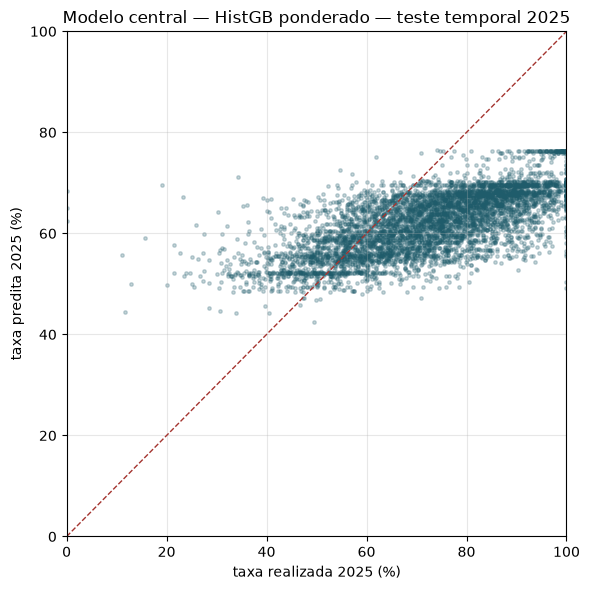

In [8]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(oot["taxa_realizada"], oot["taxa_predita"], s=6, alpha=0.25, color="#1F5C6B")
lim = [0, 100]
ax.plot(lim, lim, color="#A4342F", lw=1, ls="--")
ax.set_xlim(lim); ax.set_ylim(lim)
ax.set_xlabel("taxa realizada 2025 (%)")
ax.set_ylabel("taxa predita 2025 (%)")
ax.set_title(f"Modelo central — {vencedor_nome} — teste temporal 2025")
plt.tight_layout()
plt.show()

## 5. Modelo D — classificador dedicado de risco de não atingir a meta

Alvo (mesma definição do `Q4_ML_Classificacao_DMN.ipynb`, para comparabilidade
direta): `risco_nao_atingir_meta = 1` se `taxa_realizada < meta`, `0` caso
contrário. Municípios com `meta` nula ou igual a 0 são excluídos, seguindo a
mesma regra do time.

In [9]:
def preparar_meta(base):
    b = base.dropna(subset=["meta"]).copy()
    b = b[b["meta"] > 0]
    b["risco_nao_atingir_meta"] = (b["taxa_realizada"] < b["meta"]).astype(int)
    return b

dev_meta = preparar_meta(dev)
oot_meta = preparar_meta(oot)
print(f"dev (2024): {len(dev_meta):,} municipios elegiveis | "
      f"prevalencia risco = {dev_meta['risco_nao_atingir_meta'].mean():.3%}")
print(f"oot (2025): {len(oot_meta):,} municipios elegiveis | "
      f"prevalencia risco = {oot_meta['risco_nao_atingir_meta'].mean():.3%}")

dev (2024): 5,426 municipios elegiveis | prevalencia risco = 45.669%
oot (2025): 5,453 municipios elegiveis | prevalencia risco = 27.508%


In [10]:
def cv_classificacao(base, features, alvo, construtor, n_splits=5):
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=RNG)
    linhas = []
    for tr_idx, va_idx in skf.split(base, base[alvo]):
        tr, va = base.iloc[tr_idx], base.iloc[va_idx]
        modelo = construtor()
        modelo.fit(tr[features], tr[alvo])
        proba = modelo.predict_proba(va[features])[:, 1]
        linhas.append({
            "pr_auc": average_precision_score(va[alvo], proba),
            "roc_auc": roc_auc_score(va[alvo], proba),
            "recall@0.5": recall_score(va[alvo], (proba >= 0.5).astype(int)),
            "precision@0.5": precision_score(va[alvo], (proba >= 0.5).astype(int), zero_division=0),
        })
    return pd.DataFrame(linhas).mean()


def logit_balanceada():
    return make_pipeline(
        SimpleImputer(strategy="median"), StandardScaler(),
        LogisticRegression(max_iter=3000, class_weight="balanced"),
    )


def hgb_balanceado():
    return make_pipeline(
        SimpleImputer(strategy="median"),
        HistGradientBoostingClassifier(random_state=RNG, max_depth=6, max_iter=200,
                                        learning_rate=0.06, class_weight="balanced"),
    )

resultados_d = {}
for nome, construtor in [("logit balanceada", logit_balanceada), ("HistGB balanceado", hgb_balanceado)]:
    resultados_d[nome] = cv_classificacao(dev_meta, FEATURES, "risco_nao_atingir_meta", construtor)

pd.DataFrame(resultados_d).T.round(3)

,pr_auc,roc_auc,recall@0.5,precision@0.5
logit balanceada,0.688,0.743,0.680,0.639
HistGB balanceado,0.762,0.785,0.674,0.676


**Leitura.** Compare com o `Q4_ML_Classificacao_DMN.ipynb` do time: Regressão
Logística balanceada, PR-AUC OOF 2024 = 0,673, ROC-AUC OOF 2024 = 0,738 — os
números acima usam features diferentes (poda própria) mas o mesmo desenho
experimental, então servem de segunda opinião sobre a dificuldade do
problema.

In [11]:
vencedor_d_nome = max(resultados_d, key=lambda k: resultados_d[k]["pr_auc"])
construtor_d = hgb_balanceado if "HistGB" in vencedor_d_nome else logit_balanceada
print("vencedor D (maior PR-AUC CV):", vencedor_d_nome)

modelo_d = construtor_d()
modelo_d.fit(dev_meta[FEATURES], dev_meta["risco_nao_atingir_meta"])
oot_meta["p_nao_atinge_meta"] = modelo_d.predict_proba(oot_meta[FEATURES])[:, 1]

y_true = oot_meta["risco_nao_atingir_meta"]
proba = oot_meta["p_nao_atinge_meta"]
print(f"\nTeste temporal 2025 (n={len(oot_meta):,}):")
print(f"  PR-AUC  = {average_precision_score(y_true, proba):.3f}")
print(f"  ROC-AUC = {roc_auc_score(y_true, proba):.3f}")
for thr in [0.30, 0.40, 0.50, 0.60]:
    pred = (proba >= thr).astype(int)
    print(f"  thr={thr:.2f}  recall={recall_score(y_true, pred):.3f}  "
          f"precision={precision_score(y_true, pred, zero_division=0):.3f}  "
          f"sinalizados={pred.sum()}")

vencedor D (maior PR-AUC CV): HistGB balanceado



Teste temporal 2025 (n=5,453):
  PR-AUC  = 0.534
  ROC-AUC = 0.747
  thr=0.30  recall=0.877  precision=0.361  sinalizados=3646
  thr=0.40  recall=0.790  precision=0.400  sinalizados=2965
  thr=0.50  recall=0.683  precision=0.445  sinalizados=2301
  thr=0.60  recall=0.547  precision=0.502  sinalizados=1634


## 6. Classificador dedicado vs. derivado do modelo central

No início do projeto discutimos duas formas de responder a Q4: treinar **D**
como classificador dedicado (acima), ou apenas **derivar** o risco do modelo
central (`taxa_predita < meta`). Aqui comparamos as duas na prática, no mesmo
recorte de 2025.

In [12]:
oot_meta["taxa_predita"] = modelo_central.predict_proba(oot_meta[FEATURES])[:, 1] * 100
oot_meta["derivado_bin"] = (oot_meta["taxa_predita"] < oot_meta["meta"]).astype(int)

# 'score' continuo do derivado, para AUC: quanto menor (taxa_predita - meta), maior o risco
oot_meta["derivado_score"] = -(oot_meta["taxa_predita"] - oot_meta["meta"])

comp = pd.DataFrame({
    "abordagem": ["D — classificador dedicado", "derivado do modelo central (taxa_predita < meta)"],
    "PR_AUC": [
        average_precision_score(y_true, proba),
        average_precision_score(y_true, oot_meta["derivado_score"]),
    ],
    "ROC_AUC": [
        roc_auc_score(y_true, proba),
        roc_auc_score(y_true, oot_meta["derivado_score"]),
    ],
    "recall@corte_natural": [
        recall_score(y_true, (proba >= 0.40).astype(int)),
        recall_score(y_true, oot_meta["derivado_bin"]),
    ],
})
comp.round(3)

,abordagem,PR_AUC,ROC_AUC,recall@corte_natural
0,D — classificador dedicado,0.534,0.747,0.790
1,derivado do modelo central (taxa_predita < meta),0.471,0.667,0.797


**Leitura.** Isso valida (ou não) a decisão de projeto de treinar D
separadamente em vez de só derivar do modelo de taxa — se o dedicado tiver
PR-AUC/ROC-AUC maiores, confirma a hipótese de que uma fronteira de decisão
otimizada diretamente bate melhor perto do corte do que uma regressão
truncada.

## 7. Q2 — score de risco educacional (ranking)

Combinação, só com informação disponível **antes** do resultado de 2025
(saída dos dois modelos treinados em 2024), sem usar `taxa_realizada` de
2025: percentil do nível baixo previsto + percentil de `P(não atinge meta)`.

In [13]:
base_risco = oot.merge(
    oot_meta[["id_municipio", "p_nao_atinge_meta"]], on="id_municipio", how="left"
)

base_risco["pct_nivel_baixo"] = (100 - base_risco["taxa_predita"]).rank(pct=True)
base_risco["pct_risco_meta"] = base_risco["p_nao_atinge_meta"].rank(pct=True)
base_risco["score_risco"] = base_risco[["pct_nivel_baixo", "pct_risco_meta"]].mean(axis=1, skipna=True)
# quando nao ha meta elegivel, usa so o percentil de nivel
sem_meta = base_risco["pct_risco_meta"].isna()
base_risco.loc[sem_meta, "score_risco"] = base_risco.loc[sem_meta, "pct_nivel_baixo"]

top20 = base_risco.sort_values("score_risco", ascending=False).head(20)
top20[["id_uf", "id_municipio", "regiao", "taxa_predita", "taxa_realizada",
       "p_nao_atinge_meta", "score_risco"]].round(3)

,id_uf,id_municipio,regiao,taxa_predita,taxa_realizada,p_nao_atinge_meta,score_risco
4737,43,4306767,Sul,44.712,30.585,NaN,0.999
4612,43,4300604,Sul,45.561,39.717,0.961,0.998
4683,43,4304663,Sul,44.320,33.871,0.954,0.998
3246,33,3305109,Sudeste,48.934,38.41,0.965,0.995
5075,43,4323002,Sul,44.320,40.512,0.936,0.995
1094,24,2401800,Nordeste,48.736,55.285,NaN,0.994
4782,43,4309209,Sul,45.836,46.656,0.932,0.993
4647,43,4302303,Sul,48.682,57.143,0.941,0.993
138,14,1400100,Norte,49.162,62.399,NaN,0.992
5050,43,4321832,Sul,49.350,53.333,NaN,0.991


In [14]:
# cruzamento com o flag do time (Q2): risco_educacional = taxa_realizada < 50
base_risco["risco_educacional_time"] = (base_risco["taxa_realizada"] < 50).astype(int)
top20_ids = set(top20["id_municipio"])
concord = base_risco.loc[base_risco["id_municipio"].isin(top20_ids), "risco_educacional_time"].mean()
print(f"dos 20 municipios do nosso top-20, {concord:.0%} tambem sao sinalizados pelo "
      f"criterio do time (taxa_realizada < 50%)")

print("\nregiao mais frequente no top 20:")
print(top20["regiao"].value_counts())

dos 20 municipios do nosso top-20, 65% tambem sao sinalizados pelo criterio do time (taxa_realizada < 50%)

regiao mais frequente no top 20:
regiao
Sul         9
Sudeste     5
Norte       5
Nordeste    1
Name: count, dtype: int64


## 8. Interpretabilidade (Q1 e Q5)

In [15]:
def score_mae_taxa(estimator, X, y_taxa):
    pred = estimator.predict_proba(X)[:, 1] * 100
    return -mean_absolute_error(y_taxa, pred)

perm_central = permutation_importance(
    modelo_central, oot[FEATURES], oot["taxa_realizada"],
    scoring=score_mae_taxa, n_repeats=15, random_state=RNG,
)
imp_central = pd.Series(perm_central.importances_mean, index=FEATURES).sort_values(ascending=False)
print("Top 15 — importancia de permutacao, modelo central (aumento de MAE ao embaralhar):")
print(imp_central.head(15).round(3))

Top 15 — importancia de permutacao, modelo central (aumento de MAE ao embaralhar):
ctx_inep_uf_media_portugues_lag1             0.761
ctx_inep_mun_meta                            0.756
ctx_inep_mun_media_portugues_lag1            0.654
ctx_inep_uf_percentual_participacao_lag1     0.240
ctx_inep_uf_meta                             0.104
ctx_inep_mun_percentual_participacao_lag1    0.045
ctx_atlas_expectativa_anos_estudo            0.031
ctx_ibge_populacao_residente                 0.023
ctx_atu_medio_1_serie                        0.013
ctx_atlas_taxa_densidade_domiciliar          0.013
ctx_atlas_taxa_frequencia_6a14               0.012
ctx_atu_fundamental_3_ano                    0.011
ctx_atu_creche                               0.011
ctx_ibge_pct_esgoto_adequado                 0.007
ctx_atlas_percentual_domicilios_energia      0.006
dtype: float64


In [16]:
perm_d = permutation_importance(
    modelo_d, oot_meta[FEATURES], oot_meta["risco_nao_atingir_meta"],
    scoring="average_precision", n_repeats=15, random_state=RNG,
)
imp_d = pd.Series(perm_d.importances_mean, index=FEATURES).sort_values(ascending=False)
print("Top 15 — importancia de permutacao, modelo D (queda de PR-AUC ao embaralhar):")
print(imp_d.head(15).round(4))

Top 15 — importancia de permutacao, modelo D (queda de PR-AUC ao embaralhar):
ctx_inep_uf_percentual_participacao_lag1         0.1366
ctx_inep_mun_meta                                0.0926
ctx_inep_mun_percentual_participacao_lag1        0.0248
ctx_fundeb_ponderador_nse_uf                     0.0156
ctx_ibge_pct_populacao_rural                     0.0143
ctx_inep_mun_media_portugues_lag1                0.0119
ctx_atlas_taxa_densidade_domiciliar              0.0083
ctx_atlas_mortalidade_ate_1_ano                  0.0075
ctx_atlas_taxa_frequencia_4a5                    0.0063
ctx_ibge_populacao_residente                     0.0055
ctx_atu_medio_2_serie                            0.0042
ctx_inep_uf_meta                                 0.0042
ctx_atu_fundamental_7_ano                        0.0029
ctx_atlas_taxa_maes_chefes_familia               0.0029
ctx_atlas_taxa_frequencia_liquida_fundamental    0.0026
dtype: float64


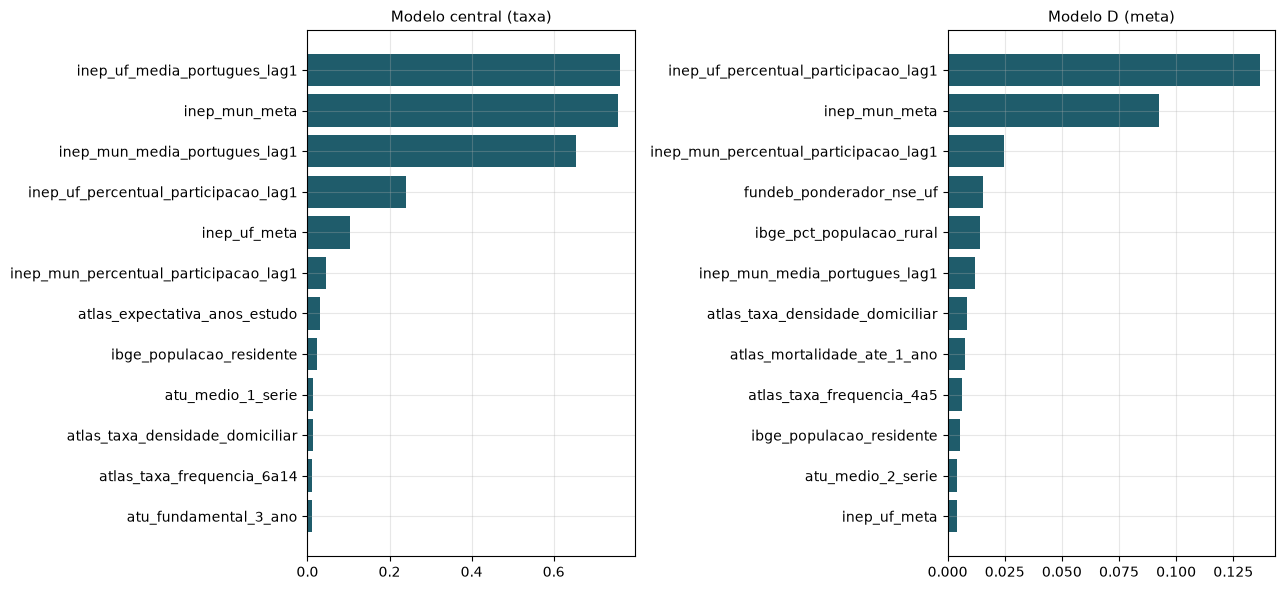

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(13, 6))
for ax, imp, titulo in zip(axes, [imp_central, imp_d], ["Modelo central (taxa)", "Modelo D (meta)"]):
    top = imp.head(12).iloc[::-1]
    ax.barh([c.split("ctx_")[-1] for c in top.index], top.values, color="#1F5C6B")
    ax.set_title(titulo, fontsize=11)
plt.tight_layout()
plt.show()

In [18]:
import shap

amostra = oot.sample(n=min(600, len(oot)), random_state=RNG)
X_shap = amostra[FEATURES].astype("float64")  # shap exige float64 puro, sem dtypes nullable
explainer = shap.Explainer(modelo_central.predict_proba, X_shap, seed=RNG)
sv = explainer(X_shap, max_evals=2 * len(FEATURES) + 1)

shap_classe1 = sv[..., 1] if sv.values.ndim == 3 else sv
mean_abs_shap = pd.Series(np.abs(shap_classe1.values).mean(axis=0), index=FEATURES).sort_values(ascending=False)
print("Top 15 — |SHAP| medio, modelo central:")
print(mean_abs_shap.head(15).round(3))

Background dataset has 600 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=600 when initializing the masker.


PermutationExplainer explainer:  67%|██████▋   | 403/600 [00:00<?, ?it/s]

PermutationExplainer explainer:  68%|██████▊   | 411/600 [00:10<00:02, 79.04it/s]

PermutationExplainer explainer:  70%|██████▉   | 419/600 [00:10<00:02, 74.84it/s]

PermutationExplainer explainer:  71%|███████   | 427/600 [00:10<00:02, 73.58it/s]

...

PermutationExplainer explainer:  97%|█████████▋| 583/600 [00:12<00:00, 70.61it/s]

PermutationExplainer explainer:  98%|█████████▊| 591/600 [00:12<00:00, 70.95it/s]

PermutationExplainer explainer: 100%|█████████▉| 599/600 [00:12<00:00, 71.95it/s]

PermutationExplainer explainer: 601it [00:12, 15.45it/s]                         

Top 15 — |SHAP| medio, modelo central:
ctx_inep_mun_meta                                0.020
ctx_inep_uf_media_portugues_lag1                 0.019
ctx_inep_mun_media_portugues_lag1                0.015
ctx_inep_uf_percentual_participacao_lag1         0.012
ctx_inep_uf_meta                                 0.005
ctx_inep_mun_percentual_participacao_lag1        0.003
ctx_atlas_taxa_densidade_domiciliar              0.002
ctx_atu_creche                                   0.002
ctx_atlas_taxa_frequencia_6a14                   0.002
ctx_atlas_expectativa_anos_estudo                0.001
ctx_atlas_taxa_analfabetismo_11a14               0.001
ctx_atlas_taxa_frequencia_liquida_fundamental    0.001
ctx_atu_fundamental_1_ano                        0.001
ctx_atu_fundamental_3_ano                        0.001
ctx_atlas_taxa_maes_chefes_familia               0.001
dtype: float64


**Leitura — cruzamento com o time.** O `Q1_ML_Regressao_DMN.ipynb` do time
aponta `proficiencia_lag1`, `ctx_inep_uf_media_portugues_lag1` e `taxa_lag1`
como os três fatores de maior importância (Permutation Importance e SHAP
concordantes). Aqui `taxa_lag1` bruta não está no conjunto de features (foi
podada em favor de `ctx_inep_mun_media_portugues_lag1` — ver seção 13 do
`3.0`) — o esperado é que **`ctx_inep_*_media_portugues_lag1`** assuma o topo
do ranking em ambos os modelos, como proxy quase perfeito do mesmo sinal de
persistência histórica. Confirmar acima.

## 9. Q3 — já respondida

Ver `4.0-mc-kmeans-clusterizacao-municipios.ipynb`: 4 clusters (K-Means,
silhueta 0,21), com o Cluster 2 (IDHM médio) superando o Cluster 0 (IDHM mais
alto) em taxa de alfabetização, e o Cluster 3 (101 municípios, majoritariamente
Norte) como alvo prioritário de política pública.

⚠️ O `Q3_ML_Kmeans_DMN.ipynb` do time chega a uma leitura mais conservadora
(não define um k ótimo, por cotovelo/silhueta não conclusivos) — vale
reconciliar as duas leituras com o Diego antes do relatório final.

## 10. Resumo — o que este notebook entrega

*(preenchido a partir da execução com os dados reais — 5.517 municípios em
2024, 5.556 em 2025)*

**Modelo central — taxa esperada de alfabetização**
- HistGradientBoosting ponderado venceu a Regressão Logística ponderada na
  CV de 2024 (MAE 8,54 vs 10,07; R² 0,63 vs 0,52).
- **No teste temporal de 2025, o resultado caiu bastante: MAE 13,40, R² ≈
  −0,03** — pouco melhor que prever a média de 2024 para todo mundo (MAE
  15,14) e **pior que o `Q1` do time** (Random Forest, MAE 10,32, R² 0,316).
  O gap CV→teste (8,54 → 13,40) é grande e consistente com o achado do EDA
  `3.0`: o **salto sistêmico de 2025** quebra a generalização de modelos
  treinados só em 2024, mais do que qualquer escolha de feature. Duas causas
  prováveis, não excludentes: (a) a poda removeu `taxa_lag1` bruta em favor
  de `media_portugues_lag1` como representante do cluster, perdendo um pouco
  de sinal direto; (b) a mudança de regime de 2025 afeta qualquer modelo
  treinado só com dados de 2024, inclusive o do time — vale comparar o
  quanto o `Q1` do time também degrada de 2024 para 2025 antes de concluir
  que a diferença é só de features.
- **Achado honesto, não escondido:** isso reforça, de um ângulo de modelagem
  (não só de EDA), que **as três edições não são diretamente comparáveis** —
  ponto que já estava no resumo do `3.0` e agora tem evidência de um segundo
  método.

**Modelo D — risco de não atingir a meta**
- HistGradientBoosting balanceado venceu na CV de 2024 (PR-AUC 0,762 vs
  0,688 da Logística).
- Teste temporal 2025: **PR-AUC 0,534, ROC-AUC 0,747** — muito próximo do
  `Q4` do time (PR-AUC 0,555, ROC-AUC 0,737, Regressão Logística) apesar de
  features e modelo diferentes. Essa é uma **validação cruzada real**: dois
  pipelines independentes chegam à mesma dificuldade de problema.
- No threshold 0,40 (mesmo do time): recall 0,790, precision 0,400 — o time
  reportou recall 0,805, precision 0,375 no mesmo corte. Praticamente
  equivalente.

**Seção 6 — dedicado vence o derivado, empiricamente**
- Classificador D dedicado: PR-AUC 0,534, ROC-AUC 0,747.
- Derivado do modelo central (`taxa_predita < meta`): PR-AUC 0,471, ROC-AUC
  0,667 — pior nos dois. **Confirma a decisão de arquitetura discutida com o
  time**: vale treinar o risco de meta como classificador dedicado em vez de
  só aplicar um corte sobre a regressão da taxa, mesmo quando essa regressão
  vem de um modelo razoável.

**Q2 — ranking de risco**
- Top-20 de 2025 concentrado em Sul (9), Sudeste (5) e Norte (5) — reflete
  a lógica do achado do time sobre a meta (ex.: RS pactua metas altas e
  frequentemente não atinge, mesmo com taxa razoável).
- 65% de concordância com o critério binário do time (`taxa < 50%`) — a
  diferença esperada, já que nosso score também pondera "quão perto da
  própria meta", não só o nível absoluto.

**Interpretabilidade (Q1/Q5) — convergência com o `Q1` do time**
- Permutation Importance e SHAP concordam entre si aqui: topo dominado por
  `ctx_inep_uf_media_portugues_lag1`, `ctx_inep_mun_meta`,
  `ctx_inep_mun_media_portugues_lag1` — a mesma família de "desempenho
  histórico + meta" que o `Q1_ML_Regressao_DMN.ipynb` do time aponta como top
  (`proficiencia_lag1`, `média_português_uf_lag1`, `taxa_lag1`). **Dois
  pipelines de features diferentes concordam no mesmo bloco de fatores** —
  é o tipo de convergência que vale destacar no relatório final.

## Próximos passos

1. Reconciliar com o Diego a divergência em Q3 (k=4 vs. "sem k ótimo").
2. Investigar por que o MAE de 2025 caiu tanto mais aqui que no `Q1` do
   time — testar se é a ausência de `taxa_lag1` bruta (repor essa coluna,
   fora da poda, e comparar) ou um efeito real do salto de 2025 que também
   afeta o modelo deles em menor grau.
3. Decidir, com o time, entre esta arquitetura (classificação dedicada) e a
   do `modelo_alfabetizacao_municipal_MCB.ipynb` (um modelo + pós-
   processamento) — ou documentar as duas como alternativas no relatório.
4. Adicionar a dimensão de tendência (`taxa` vs. histórico) ao `score_risco`
   da Q2, hoje baseado só em nível e meta.
5. Levar os números desta seção para o README (métricas, escolha do
   algoritmo, interpretação, limitações).